# Correlação e Covariância — Prática com Python

## 1. Importando bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Dataset de peso, altura e idade

Vamos criar um dataset simulado com peso, altura e idade de 100 pessoas. Na vida real, esperaríamos que peso e altura estivessem positivamente correlacionados.

In [3]:
np.random.seed(42)
n = 100

# Altura em cm (média 168, desvio ~10)
altura = np.random.normal(168, 10, n)

# Peso em kg — correlacionado com altura + ruído
# Pessoas mais altas tendem a pesar mais: peso ≈ 0.8 * altura - 60 + ruído
peso = 0.8 * altura - 60 + np.random.normal(0, 5, n)

# Idade — não correlacionada com peso/altura neste dataset
idade = np.random.randint(18, 65, n)

dados = pd.DataFrame({
    'Altura (cm)': altura,
    'Peso (kg)': peso,
    'Idade': idade
})

dados.head(10)

,Altura (cm),Peso (kg),Idade
0,172.967142,71.296860,19
1,166.617357,71.190659,43
2,174.476885,77.867936,34
3,183.230299,82.572853,57
4,165.658466,71.720344,50
5,165.658630,74.547159,26
6,183.792128,96.464632,60
7,175.674347,81.412367,56
8,163.305256,71.931957,46
9,173.425600,78.368251,59


## 3. Visualização: gráfico de dispersão

O gráfico de dispersão nos dá uma intuição visual sobre a relação entre variáveis.

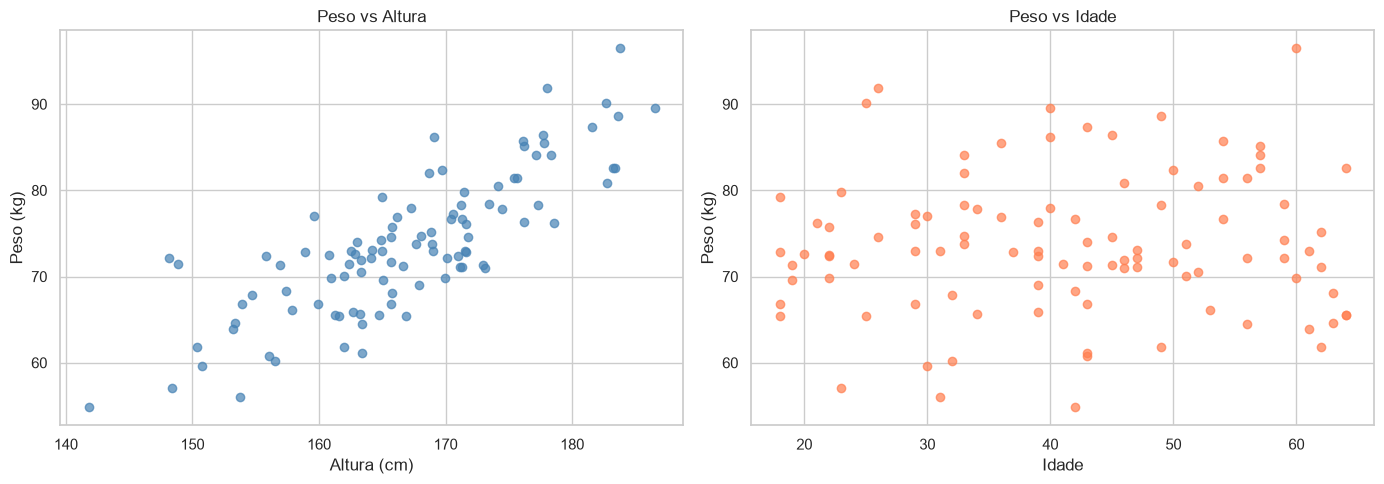

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peso vs Altura
axes[0].scatter(dados['Altura (cm)'], dados['Peso (kg)'], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Altura (cm)')
axes[0].set_ylabel('Peso (kg)')
axes[0].set_title('Peso vs Altura')

# Peso vs Idade
axes[1].scatter(dados['Idade'], dados['Peso (kg)'], alpha=0.7, color='coral')
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('Peso (kg)')
axes[1].set_title('Peso vs Idade')

plt.tight_layout()
plt.show()

## 4. Covariância

A covariância mede como duas variáveis variam juntas:

$$\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

- **Positiva**: quando uma aumenta, a outra tende a aumentar
- **Negativa**: quando uma aumenta, a outra tende a diminuir
- **Próxima de 0**: sem relação linear

In [5]:
# Matriz de covariância
cov_matrix = dados.cov()
print('Matriz de Covariância:')
print(cov_matrix.round(2))
print()

# Covariância específica entre peso e altura
cov_peso_altura = dados['Peso (kg)'].cov(dados['Altura (cm)'])
print(f'Cov(Peso, Altura) = {cov_peso_altura:.2f}')

Matriz de Covariância:
             Altura (cm)  Peso (kg)   Idade
Altura (cm)        82.48      60.07   12.05
Peso (kg)          60.07      66.07    6.88
Idade              12.05       6.88  186.46

Cov(Peso, Altura) = 60.07


### Interpretação

- `Cov(Peso, Altura) > 0` → peso e altura variam na mesma direção ✅
- `Cov(Peso, Idade) ≈ 0` → não há relação linear entre peso e idade

⚠️ **Problema**: o valor da covariância depende da escala. Não conseguimos comparar diretamente covariâncias de pares diferentes.

## 5. Correlação de Pearson

A correlação normaliza a covariância pelos desvios padrão:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

Resultado sempre entre **−1 e +1**.

In [6]:
# Matriz de correlação
corr_matrix = dados.corr()
print('Matriz de Correlação (Pearson):')
print(corr_matrix.round(3))

Matriz de Correlação (Pearson):
             Altura (cm)  Peso (kg)  Idade
Altura (cm)        1.000      0.814  0.097
Peso (kg)          0.814      1.000  0.062
Idade              0.097      0.062  1.000


### Visualização: heatmap de correlação

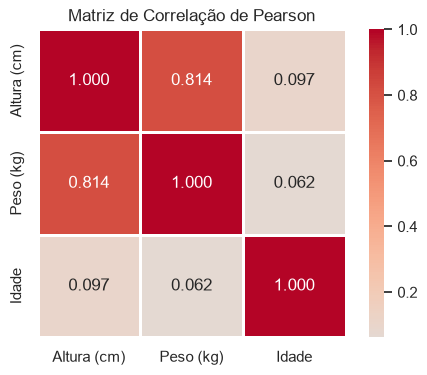

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=2)
plt.title('Matriz de Correlação de Pearson')
plt.show()